---
downloads: []
---

(sec:singular_value_decomposition)=

# Singular Value Decomposition

In Section [](#sec:eigenvalue_algorithms), we have seen that a square matrix
can be decomposed according to:
$$
\bm{A} = \bm{Q}\bm{\Lambda}\bm{Q}^{-1} \,,
$$
where $\bm{Q}$ is the matrix of eigenvectors and $\bm{\Lambda}$ is the diagonal
matrix of eigenvalues. This decomposition is called the eigenvalue decomposition.

A natural question is whether we can decompose a non-square matrix in a similar way.
The answer is yes, and the decomposition is called the 
*singular value decomposition*, or SVD for short.

## Theoretical Foundations



Let $\bm{A} \in \mathbb{R}^{m \times n}$ be a matrix, where $m$ and $n$ can be different. 
The SVD of $\bm{A}$ is given by
```{math}
:enumerated: true
:label: eq:svd_definition
\bm{A} = \bm{U}\bm{\Sigma}\bm{V}^\intercal \, .
```
Here, $\bm{U}$ and $\bm{V}$ are [orthogonal matrices](wiki:orthogonal_matrix)
and $\bm{\Sigma}$ is a rectangular diagonal matrix with non-negative entries
$\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_p \geq 0$, where $p = \min(m,n)$.
The numbers $\sigma_i$ are the *singular values*. 
The columns $\vec{u}_i$ of $\bm{U}$ are the *left singular vectors*, 
and the columns $\vec{v}_i$ of $\bm{V}$ are the *right singular vectors*.

Writing out the matrix multiplication in Eq. [](#eq:svd_definition) explicitly, we have
```{math}
:enumerated: true
:label: eq:singular_value_decomposition
\begin{align*}
    \bm{A} &= \bm{U} \bm{\Sigma} \bm{V}^\intercal \\
    &= \begin{pmatrix}
        \vert & \vert &  & \vert \\
        \vec{u}_ 1 & \vec{u}_ 2 & \cdots & \vec{u}_ m \\
        \vert & \vert &  & \vert
    \end{pmatrix}
    \left(\begin{array}{cccc|ccc}
        \sigma_1 & 0 & \cdots & 0 & 0 & \cdots & 0 \\ 
        0 & \sigma_2 & \cdots & 0 & 0 & \cdots & 0 \\
        \vdots & \vdots & \ddots & 0 & \vdots & \ddots & \vdots \\
        0 & 0 & \cdots & \sigma_p & 0 & \cdots & 0 \\ \hline
        0 & 0 & \cdots & 0 & 0 & \cdots & 0 \\
        \vdots & \vdots & \ddots & \vdots & \vdots & \ddots & \vdots \\
        0 & 0 & \cdots & 0 & 0 & \cdots & 0
    \end{array}\right)
    \begin{pmatrix}
        \text{---}\ \vec{v}_ 1^\intercal\ \text{---} \\
        \text{---}\ \vec{v}_ 2^\intercal\ \text{---} \\
        \vdots \\
        \text{---}\ \vec{v}_ n^\intercal\ \text{---}
    \end{pmatrix} \\
    &= \sigma_1 \vec{u}_ 1 \vec{v}_ 1^\intercal + \sigma_2 \vec{u}_ 2 \vec{v}_ 2^\intercal + \cdots + \sigma_p \vec{u}_ p \vec{v}_ p^\intercal \\
    &= \sum_{i=1}^p \sigma_i \vec{u}_ i \vec{v}_ i^\intercal\,.
\end{align*}
```

This form is the key idea for the rest of the section. 
It says that a matrix can be decomposed into ordered components.
Each component has a left pattern $\vec{u}_i$, a right pattern $\vec{v}_i$, 
 and an importance given by the corresponding singular value $\sigma_i$.

The product $\vec{u}_i \vec{v}_i^\intercal$ is called the [*outer product*](wiki:outer_product)
of $\vec{u}_i$ and $\vec{v}_i$, sometimes also denoted as $\vec{u}_i \otimes \vec{v}_i$.

An intuitive definition of the outer product and its relation 
to the inner product (also known as the dot product or scalar product) is shown in 
Fig.&nbsp;[](#fig:inner_outer_product).
The last line of Eq. [](#eq:singular_value_decomposition) shows that 
the original matrix $\bm{A}$ can be reconstructed by summing up the 
matrices created by the outer products of the left and right singular vectors, 
weighted by their singular values.

:::{figure} /assets/figures/spectral_analysis/inner_outer_product.svg
:label: fig:inner_outer_product
:align: center
:alt: Visualisation of inner product and outer product
A visualisation of the inner product and outer product of two vectors $\vec{u}$ and $\vec{v}$. 
The inner product $\vec{u} \cdot \vec{v}$ or $\vec{u}^\intercal \vec{v}$ is a scalar, 
while the outer product $\vec{u} \otimes \vec{v}$ or $\vec{u}\vec{v}^\intercal$ is a matrix.
:::

### Motivation

Suppose seven chemistry students rate five textbooks using 1 to 5 stars. A value of 0 means that the student did not rate the book.

:::{table}
<table class="book-rating-table">
  <tr style="line-height: 0;">
    <th></th>
    <th style="text-align: center; padding: 0; line-height: 0; font-size: 0;"><img src="/assets/figures/spectral_analysis/atkins.jpg" alt="Atkins textbook" height="150"></th>
    <th style="text-align: center; padding: 0; line-height: 0; font-size: 0;"><img src="/assets/figures/spectral_analysis/szabo_ostlund.jpg" alt="Szabo/Ostlund textbook" height="150"></th>
    <th style="text-align: center; padding: 0; line-height: 0; font-size: 0;"><img src="/assets/figures/spectral_analysis/helgaker.jpg" alt="Helgaker textbook" height="150"></th>
    <th style="text-align: center; padding: 0; line-height: 0; font-size: 0;"><img src="/assets/figures/spectral_analysis/clayden.jpg" alt="Clayden textbook" height="150"></th>
    <th style="text-align: center; padding: 0; line-height: 0; font-size: 0;"><img src="/assets/figures/spectral_analysis/klein.jpg" alt="Klein textbook" height="150"></th>
  </tr>
  <tr>
    <th style="text-align: right; padding: 6px 8px; line-height: 1; ">Student</th>
    <th style="text-align: center; padding: 6px 8px; line-height: 1; border-bottom: 1px solid black;">Atkins</th>
    <th style="text-align: center; padding: 6px 8px; line-height: 1; border-bottom: 1px solid black;">Szabo & Ostlund</th>
    <th style="text-align: center; padding: 6px 8px; line-height: 1; border-bottom: 1px solid black;">Helgaker</th>
    <th style="text-align: center; padding: 6px 8px; line-height: 1; border-bottom: 1px solid black;">Clayden</th>
    <th style="text-align: center; padding: 6px 8px; line-height: 1; border-bottom: 1px solid black;">Klein</th>
  </tr>
  <tr>
    <td style="text-align: right; padding: 6px 8px; line-height: 1; border-right: 1px solid black;">1</td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;"><strong>1</strong></td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;"><strong>1</strong></td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;"><strong>1</strong></td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;">0</td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;">0</td>
  </tr>
  <tr>
    <td style="text-align: right; padding: 6px 8px; line-height: 1; border-right: 1px solid black;">2</td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;"><strong>3</strong></td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;"><strong>3</strong></td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;"><strong>3</strong></td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;">0</td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;">0</td>
  </tr>
  <tr>
    <td style="text-align: right; padding: 6px 8px; line-height: 1; border-right: 1px solid black;">3</td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;"><strong>4</strong></td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;"><strong>4</strong></td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;"><strong>4</strong></td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;">0</td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;">0</td>
  </tr>
  <tr>
    <td style="text-align: right; padding: 6px 8px; line-height: 1; border-right: 1px solid black;">4</td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;"><strong>5</strong></td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;"><strong>5</strong></td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;"><strong>5</strong></td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;">0</td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;">0</td>
  </tr>
  <tr>
    <td style="text-align: right; padding: 6px 8px; line-height: 1; border-right: 1px solid black;">5</td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;">0</td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;"><strong>2</strong></td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;">0</td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;"><strong>4</strong></td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;"><strong>4</strong></td>
  </tr>
  <tr>
    <td style="text-align: right; padding: 6px 8px; line-height: 1; border-right: 1px solid black;">6</td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;">0</td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;">0</td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;">0</td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;"><strong>5</strong></td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;"><strong>5</strong></td>
  </tr>
  <tr>
    <td style="text-align: right; padding: 6px 8px; line-height: 1; border-right: 1px solid black;">7</td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;">0</td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;"><strong>1</strong></td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;">0</td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;"><strong>2</strong></td>
    <td style="text-align: center; padding: 6px 8px; line-height: 1;"><strong>2</strong></td>
  </tr>
</table>
:::

As a matrix, this is

$$
\bm{A} =
\begin{pmatrix}
  1 & 1 & 1 & 0 & 0 \\
  3 & 3 & 3 & 0 & 0 \\
  4 & 4 & 4 & 0 & 0 \\
  5 & 5 & 5 & 0 & 0 \\
  0 & 2 & 0 & 4 & 4 \\
  0 & 0 & 0 & 5 & 5 \\
  0 & 1 & 0 & 2 & 2
\end{pmatrix} \, .
$$

We now apply SVD to $\bm{A}$ and see what we can learn from the decomposition.

In [1]:
import numpy as np

ratings = np.array([
    [1, 1, 1, 0, 0],
    [3, 3, 3, 0, 0],
    [4, 4, 4, 0, 0],
    [5, 5, 5, 0, 0],
    [0, 2, 0, 4, 4],
    [0, 0, 0, 5, 5],
    [0, 1, 0, 2, 2],
])

import altair as alt
from IPython.display import HTML, display

MATRIX_5 = 220
MATRIX_7 = 308
SYMBOL_WIDTH = 32
ROW_GAP = 20
MATRIX_TITLE_FONT_SIZE = 20
AXIS_TITLE_FONT_SIZE = 14
MATRIX_NUMBER_FONT_SIZE = 15
MATRIX_A_NUMBER_FONT_SIZE = 18
SYMBOL_FONT_SIZE = 32

svd_style = """
<style>
.vega-bindings {
  margin-top: 0.75rem;
  font-size: 16px;
  line-height: 1.45;
}
.vega-bind {
  display: flex;
  align-items: center;
  gap: 0.35rem;
  white-space: nowrap;
}
.vega-bind input[type="radio"] {
  width: 16px;
  height: 16px;
  margin-left: 1.05rem;
  margin-right: 0.25rem;
  transform: translateY(0px) scale(1.0);
  accent-color: #0b5fff;
}
.vega-bind input[type="radio"]:first-of-type {
  margin-left: 0.50rem;
}
.vega-bind input[type="checkbox"] {
  width: 16px;
  height: 16px;
  margin-left: 0.50rem;
  transform: translateY(0.5px) scale(1.2);
  accent-color: #0b5fff;
}
</style>
"""

display(HTML(svd_style))

rank = int(np.linalg.matrix_rank(ratings))
u_full, s_full, vt_full = np.linalg.svd(ratings, full_matrices=True)
sigma_full = np.zeros_like(ratings, dtype=float)
np.fill_diagonal(sigma_full, s_full)

student_labels = [str(i) for i in range(1, ratings.shape[0] + 1)]
book_labels = ['Atkins', 'S. & O.', 'Helgaker', 'Clayden', 'Klein']
concept_labels = [f'C{i}' for i in range(1, rank + 1)]
extra_u_labels = [f'_u{i}' for i in range(rank + 1, u_full.shape[1] + 1)]
extra_vt_labels = [f'_v{i}' for i in range(rank + 1, ratings.shape[1] + 1)]
u_labels = concept_labels + extra_u_labels
sigma_col_labels = concept_labels + extra_vt_labels
sigma_row_labels = concept_labels + [f'_s{i}' for i in range(rank + 1, ratings.shape[0] + 1)]
vt_labels = concept_labels + extra_vt_labels


def format_value(value, panel):
    if panel == 'A':
        return f'{value:.0f}'
    if abs(value) < 0.005:
        return '0.00'
    return f'{value:.2f}'


def axis_label(label):
    return '' if label.startswith('_') else label


def matrix_records(values, panel, row_labels, col_labels, *, component_axis=None, important=None):
    records = []
    for i, row_label in enumerate(row_labels):
        for j, col_label in enumerate(col_labels):
            component = None
            if component_axis == 'col' and j < rank:
                component = j + 1
            elif component_axis == 'row' and i < rank:
                component = i + 1
            elif component_axis == 'diag' and i == j and i < rank:
                component = i + 1

            if panel == 'A':
                in_thin = in_compact = True
            elif panel == 'U':
                in_thin = j < ratings.shape[1]
                in_compact = j < rank
            elif panel == 'Sigma':
                in_thin = i < ratings.shape[1]
                in_compact = i < rank and j < rank
            elif panel == 'VT':
                in_thin = True
                in_compact = i < rank
            else:
                in_thin = in_compact = True

            value = float(values[i, j])
            records.append({
                "panel": panel,
                "row": i,
                "col": j,
                "row_label": row_label,
                "col_label": col_label,
                "row_axis_label": axis_label(row_label),
                "col_axis_label": axis_label(col_label),
                "row_tip": f"Student {i + 1}" if panel in {"A", "U"} else axis_label(row_label),
                "col_tip": axis_label(col_label),
                "value": value,
                "label": format_value(value, panel),
                "component": component,
                "in_thin": in_thin,
                "in_compact": in_compact,
                "important": important(value, i, j) if important else False,
            })
    return records


records_a = matrix_records(
    ratings, "A", student_labels, book_labels,
    important=lambda value, i, j: abs(value) > 0,
)
records_u = matrix_records(
    u_full, "U", student_labels, u_labels,
    component_axis='col',
    important=lambda value, i, j: abs(value) >= 0.30 and j < rank,
)
records_sigma = matrix_records(
    sigma_full, "Sigma", sigma_row_labels, sigma_col_labels,
    component_axis='diag',
    important=lambda value, i, j: i == j and value > 1e-10,
)
records_vt = matrix_records(
    vt_full, "VT", vt_labels, book_labels,
    component_axis='row',
    important=lambda value, i, j: abs(value) >= 0.30 and i < rank,
)

stage = alt.param(
    name='stage',
    bind=alt.binding_radio(
        name='SVD form: ',
        options=['Full SVD', 'Thin SVD', 'Compact SVD'],
    ),
    value='Compact SVD',
)
show_important = alt.param(
    name='showImportant',
    bind=alt.binding_checkbox(name='Mark important numbers: '),
    value=True,
)
hover_u = alt.selection_point(
    name='hoverU',
    fields=['component'],
    on='mouseover',
    clear='mouseout',
    empty=False,
)
hover_sigma = alt.selection_point(
    name='hoverSigma',
    fields=['component'],
    on='mouseover',
    clear='mouseout',
    empty=False,
)
hover_vt = alt.selection_point(
    name='hoverVT',
    fields=['component'],
    on='mouseover',
    clear='mouseout',
    empty=False,
)
hover_selectors = [hover_u, hover_sigma, hover_vt]

opacity_expr = (
    'stage == "Full SVD" ? 1.0 : '
    'stage == "Thin SVD" ? (datum.in_thin ? 1.0 : 0.10) : '
    'datum.in_compact ? 1.0 : (datum.in_thin ? 0.40 : 0.10)'
)
text_opacity_expr = (
    'stage == "Full SVD" ? 1.0 : '
    'stage == "Thin SVD" ? (datum.in_thin ? 1.0 : 0.20) : '
    'datum.in_compact ? 1.0 : (datum.in_thin ? 0.50 : 0.20)'
)
important_expr = '(datum.panel == "A" && datum.important) || (showImportant && datum.important)'
highlight_expr = 'datum.component != null'


def matrix_chart(
    records,
    title,
    *,
    width,
    height,
    color_domain=None,
    color_scheme=None,
    color_type='linear',
    x_title=None,
    y_title=None,
    plain=False,
    text_color_rule='diverging',
    has_tooltip=True,
    hover_param=None,
    highlight_mode='cell',
):
    data = alt.Data(values=records)
    base = alt.Chart(data).encode(
        x=alt.X(
            'col_label:N',
            sort=None,
            title=x_title,
            axis=alt.Axis(
                orient='top',
                labelAngle=0,
                labelExpr='datum.value[0] == "_" ? "" : datum.value',
                titleFontSize=AXIS_TITLE_FONT_SIZE,
            ),
        ),
        y=alt.Y(
            'row_label:N',
            sort=None,
            title=y_title,
            axis=alt.Axis(
                labelExpr='datum.value[0] == "_" ? "" : datum.value',
                titleFontSize=AXIS_TITLE_FONT_SIZE,
            ),
        ),
        tooltip=[
            alt.Tooltip('panel:N', title='matrix'),
            alt.Tooltip('row_tip:N', title='row'),
            alt.Tooltip('col_tip:N', title='column'),
            alt.Tooltip('label:N', title='value'),
        ] if has_tooltip else [],
    )
    if plain:
        cells = base.mark_rect(fill="white", stroke="#d1d5db", strokeWidth=0.7)
        text_color = alt.value("#111827")
    else:
        cells = base.mark_rect(stroke="white", strokeWidth=0.5).encode(
            color=alt.Color(
                "value:Q",
                scale=alt.Scale(scheme=color_scheme, domain=color_domain, type=color_type),
                legend=None,
            ),
            opacity=alt.OpacityValue(alt.ExprRef(expr=opacity_expr)),
        )
        if text_color_rule == 'positive':
            text_color = alt.condition(
                f'datum.value > {0.55 * max(color_domain):.6g}',
                alt.value('white'),
                alt.value('black'),
            )
        else:
            text_color = alt.condition('abs(datum.value) > 0.45', alt.value('white'), alt.value('black'))

    number_font_size = MATRIX_A_NUMBER_FONT_SIZE if title == 'A' else MATRIX_NUMBER_FONT_SIZE

    normal_text = base.mark_text(fontSize=number_font_size).encode(
        text='label:N',
        color=text_color,
        opacity=alt.OpacityValue(alt.ExprRef(expr=text_opacity_expr)),
    )
    bold_text = base.transform_filter(important_expr).mark_text(
        fontSize=number_font_size,
        fontWeight='bold',
    ).encode(
        text='label:N',
        color=text_color,
        opacity=alt.OpacityValue(alt.ExprRef(expr=text_opacity_expr)),
    )
    if highlight_mode == 'column':
        highlight_records = [
            {'component': component, 'col_label': col_label}
            for component, col_label in sorted({
                (record['component'], record['col_label'])
                for record in records
                if record['component'] is not None
            })
        ]
        highlight_base = alt.Chart(alt.Data(values=highlight_records)).encode(
            x=alt.X('col_label:N', sort=None),
            y=alt.value(0),
            y2=alt.value(height),
        )
    elif highlight_mode == 'row':
        highlight_records = [
            {'component': component, 'row_label': row_label}
            for component, row_label in sorted({
                (record['component'], record['row_label'])
                for record in records
                if record['component'] is not None
            })
        ]
        highlight_base = alt.Chart(alt.Data(values=highlight_records)).encode(
            x=alt.value(0),
            x2=alt.value(width),
            y=alt.Y('row_label:N', sort=None),
        )
    else:
        highlight_base = base.transform_filter(highlight_expr)

    highlight_layers = [
        highlight_base.mark_rect(
            fillOpacity=0,
            stroke='#FF00FF',
            strokeWidth=3.0,
            radius=3,
        ).encode(
            strokeOpacity=alt.condition(selector, alt.value(1), alt.value(0.001)),
        )
        for selector in hover_selectors
    ]
    hover_target = base.transform_filter(highlight_expr).mark_rect(
        fill='#FFFFFF',
        fillOpacity=0.001,
        strokeOpacity=0,
    )
    if hover_param is not None:
        hover_target = hover_target.add_params(hover_param)
    return alt.layer(
        cells,
        normal_text,
        bold_text,
        *highlight_layers,
        hover_target,
    ).properties(
        title=alt.TitleParams(text=title, fontSize=MATRIX_TITLE_FONT_SIZE),
        width=width,
        height=height,
    )


chart_a = matrix_chart(
    records_a, 'A', width=MATRIX_5, height=MATRIX_7,
    x_title='books', y_title='students', plain=True,
)
chart_u = matrix_chart(
    records_u, 'U', width=MATRIX_7, height=MATRIX_7,
    color_domain=[-0.8, 0.8], color_scheme='redblue',
    x_title='concepts', y_title='students', hover_param=hover_u, highlight_mode='column',
)
chart_sigma = matrix_chart(
    records_sigma, 'Σ', width=MATRIX_5, height=MATRIX_7,
    color_domain=[0, float(s_full[0])], color_scheme='greens',
    color_type='sqrt', text_color_rule='positive',
    x_title='concepts', y_title='concepts', hover_param=hover_sigma,
    has_tooltip=False,
)
chart_vt = matrix_chart(
    records_vt, 'Vᵀ', width=MATRIX_5, height=MATRIX_5,
    color_domain=[-0.8, 0.8], color_scheme='redblue',
    x_title='books', y_title='concepts', hover_param=hover_vt, highlight_mode='row',
)


def symbol(text, *, width=SYMBOL_WIDTH, height=MATRIX_7):
    return alt.Chart(alt.Data(values=[{'text': text}])).mark_text(
        fontSize=SYMBOL_FONT_SIZE,
        fontWeight='bold',
    ).encode(text='text:N').properties(width=width, height=height)


top_row = alt.hconcat(
    chart_a,
    symbol('='),
    chart_u,
    spacing=9,
).resolve_scale(
    color='independent',
)
bottom_row = alt.hconcat(
    symbol('×'),
    chart_sigma,
    symbol('×'),
    chart_vt,
    spacing=9,
    center=True,
).resolve_scale(
    color='independent',
)
svd_interpretation_chart = alt.vconcat(
    top_row,
    bottom_row,
    spacing=ROW_GAP,
).add_params(
    stage,
    show_important,
).resolve_scale(
    color='independent',
)

svd_interpretation_chart

alt.VConcatChart(...)

Since matrix $\bm{A}$ has shape $7 \times 5$, the **full SVD** gives us

$$
\bm{A} = \bm{U}\bm{\Sigma}\bm{V}^\intercal,
\quad
\bm{U} \in \mathbb{R}^{7 \times 7},
\quad
\bm{\Sigma} \in \mathbb{R}^{7 \times 5},
\quad
\bm{V} \in \mathbb{R}^{5 \times 5}.
$$

Because $\bm{A}$ has only five columns, the last two columns of $\bm{U}$ cannot
contribute to the product. Removing these unused columns gives the *thin SVD*,
sometimes also called the *economic SVD*:

$$
\bm{A} = \hat{\bm{U}}\hat{\bm{\Sigma}}\bm{V}^\intercal,
\quad
\hat{\bm{U}} \in \mathbb{R}^{7 \times 5},
\quad
\hat{\bm{\Sigma}} \in \mathbb{R}^{5 \times 5}.
$$

In this example, two of the five singular values are zero. The corresponding
singular vectors do not contribute to the decomposition either. If we keep only
the $r$ nonzero singular values, where here $r = 3$, we obtain the *compact SVD*:

$$
\bm{A} = \bm{U}_{r}\,\bm{\Sigma}_{r}\,\bm{V}_{r}^\intercal,
\quad
\bm{U}_r \in \mathbb{R}^{7 \times r},
\quad
\bm{\Sigma}_r \in \mathbb{R}^{r \times r},
\quad
\bm{V}_r \in \mathbb{R}^{5 \times r}.
$$

The interactive figure above shows these three versions of the same decomposition.
Use the radio buttons to switch between the full, thin, and compact SVD. The parts
that are not needed in the selected form are shown with reduced opacity: directions
outside the thin SVD are most strongly faded, while directions that belong to the
thin SVD but not to the compact SVD are only moderately faded. The checkbox marks
entries with large magnitude. 

The three nonzero singular values define three concepts, C1, C2, and C3. In
$\bm{V}^\intercal$, the first row has large entries for Atkins, Szabo & Ostlund, 
and Helgaker. This concept therefore corresponds to physical chemistry and quantum
chemistry textbooks. The second row has large entries for Clayden and Klein, so it
corresponds to organic chemistry textbooks. 
The third row is dominated by Szabo & Ostlund, and separates this book from the 
other physical and quantum chemistry textbooks.
Thus, the right singular vectors describe concepts of the columns of the data
matrix; in this example, they are textbook concepts.

The left singular vectors describe how strongly the students are associated with
these concepts. The first column of $\bm{U}$ has large entries for the first four
students, who rated the physical and quantum chemistry textbooks. The second column
has large entries for the last three students, who primarily rated the organic chemistry
textbooks. The third column is a little harder to interpret on its own. Together
with the third row of $\bm{V}^\intercal$, it shows which students rated
Szabo & Ostlund differently from what would be expected from the two broader textbook
concepts.

In the figure above, you can hover over elements contributing to a concept 
to highlight all the other elements related to the same concept.

Notice that SVD has no idea about the meaning of the rows and columns 
of the data matrix. From the numbers alone, SVD manages to find two main concepts in the data
and group the rows and columns according to these concepts.

### Low-rank Approximation

In the book rating example, we discussed that the third concept is a bit difficult to interpret.
If we look at its singular value, we see that it is much smaller than the first two. 
This suggests that the third concept is less important than the first two, 
and we can maybe ignore it without losing too much information.
This would on the one hand reduce the storage cost of the data, 
and on the other hand make it easier to interpret the data.

Therefore,
```{math}
:enumerated: true
:label: eq:rank_k_approximation
\bm{A}_k = \sum_{i=1}^{k} \sigma_i \vec{u}_i \vec{v}_i^\intercal
```
is an approximation of $\bm{A}$ that keeps only the first $k$ singular values 
and their corresponding singular vectors. It should be obvious that the best approximation
in this form is obtained for singular values sorted from largest to smallest, *i.e.*,
$\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_p \geq 0$.

The [*rank*](wiki:Rank_(linear_algebra)) of a matrix usually has a somewhat unwieldy definition
for beginners. But with the SVD, it is equivalent to the number of nonzero singular values.
Thus, Eq.&nbsp;[](#eq:rank_k_approximation) is a rank-$k$ approximation of $\bm{A}$,
or, more broadly, a low-rank approximation of $\bm{A}$.

Just like for any kind of approximation, an important question is how good the approximation is.
In the case of the low-rank approximation defined in Eq.&nbsp;[](#eq:rank_k_approximation), 
Schmidt decomposition theorem tells us that it is the *best* possible rank-$k$ approximation of $\bm{A}$
in the sense that it minimises $\|\bm{A} - \bm{A}_k\|_F$, where $\|\cdot\|_F$ denotes the
[*Frobenius norm*](wiki:Frobenius_norm) of a matrix.
This norm is defined as the square root of the sum of the squares of all entries of the matrix, *i.e.*,
```{math}
:enumerated: true
:label: eq:frobenius_norm
\|\bm{M}\|_F = \sqrt{\sum_{i=1}^m \sum_{j=1}^n |M_{ij}|^2} \,,
```
for a $m \times n$ matrix $\bm{M}$.

This theorem was later generalised by Mirsky to quite a few other matrix norms, meaning that
the low-rank approximation in Eq.&nbsp;[](#eq:rank_k_approximation) is actually
the best possible rank-$k$ approximation of $\bm{A}$ in many different senses.

:::{note} Schmidt Decomposition Theorem
:class: dropdown

Let $\bm{A} \in \mathbb{C}^{m \times n}$ be an arbitrary matrix with the SVD given by
$\bm{A} = \sum_{i=1}^p \sigma_i \vec{u}_i \vec{v}_i^\dag$, where $p = \min(m,n)$ and 
$\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_p \geq 0$. 
Then the matrix $\bm{A}_k := \sum_{i=1}^k \sigma_i \vec{u}_i \vec{v}_i^\dag$ is a *best* 
rank-$k$ approximation of $\bm{A}$ in the sense

$$
\|\bm{A} - \bm{A}_k\|_F
=
\min_{\substack{\bm{B} \in \mathbb{C}^{m \times n} \\ \mathrm{rank}(\bm{B}) \leq k}} \|\bm{A} - \bm{B}\|_F \,.
$$

The proof of this theorem requires some knowledge of linear algebra.
Interested readers can find one proof *e.g.* [here](wiki:Low-rank_approximation#Proof_of_Eckart–Young–Mirsky_theorem_(for_Frobenius_norm)).

The original theorem proven by Erhard Schmidt in 1907 is more general than the one stated here.[^schmidt_decomposition]
Its application to (finite-dimensional) matrices was rediscovered by Eckart and Young in 1936,[^eckart_young]
and is thus often called the Eckart-Young theorem.
:::

:::{note} Generalisation by Mirsky
:class: dropdown
The Schmidt-Eckart-Young theorem was generalised by Leonid Mirsky in 1960 to a wider class 
of matrix norms,[^mirsky] namely the *unitarily invariant norms*.
A norm $\|\cdot\|$ is called unitarily invariant if $\|\bm{U}\bm{A}\bm{V}\| = \|\bm{A}\|$ 
for all matrices $\bm{A}$ and all unitary matrices $\bm{U}$ and $\bm{V}$ of appropriate dimensions.

Let $\bm{A} \in \mathbb{C}^{m \times n}$ and $p = \min(m,n)$.
Let the singular values of $\bm{A}$ be $\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_p \geq 0$.
Some common examples of unitarily invariant norms are:
- the [*Frobenius norm*](wiki:Matrix_norm#Frobenius_norm) $$\|\bm{A}\|_F = \sqrt{\sum_{i=1}^m \sum_{j=1}^n |A_{ij}|^2} = \sqrt{\sum_{i=1}^p \sigma_i^2}\,,$$
- the [*spectral norm*](wiki:Matrix_norm#Spectral_norm) $$\|\bm{A}\|_2 = \max_{\|\vec{x}\|_2 = 1} \|\bm{A}\vec{x}\|_2 = \sigma_1\,,$$
- and the [*nuclear norm*](wiki:Matrix_norm#Schatten_norms) or trace norm $$\|\bm{A}\|_* = \sum_{i=1}^p \sigma_i\,.$$

All of these three norms are special cases of the [*Schatten norms*](wiki:Matrix_norm#Schatten_norms).
:::

[^schmidt_decomposition]: E. Schmidt, *Math. Ann.* **1907**, *63*, 433&ndash;476.
[^eckart_young]: C. Eckart, G. Young, *Psychometrika* **1936**, *1*, 211&ndash;218.
[^mirsky]: L. Mirsky, *Q. J. Math.* **1960**, *11*, 50&ndash;59.

## Implementation

The NumPy library provides the
[`numpy.linalg.svd`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html) 
function for computing the SVD of a matrix.

In [2]:
import numpy as np

In [3]:
ratings = np.array([
    [1, 1, 1, 0, 0],
    [3, 3, 3, 0, 0],
    [4, 4, 4, 0, 0],
    [5, 5, 5, 0, 0],
    [0, 2, 0, 4, 4],
    [0, 0, 0, 5, 5],
    [0, 1, 0, 2, 2],
])
u_full, s_full, vt_full = np.linalg.svd(ratings)

print('U shape:  ', u_full.shape)
print('S shape:  ', s_full.shape)
print('V^T shape:', vt_full.shape)

U shape:   (7, 7)
S shape:   (5,)
V^T shape: (5, 5)


Note that the variable `s_full` is not the matrix of singular values $\bm{\Sigma}$, 
but rather a 1D array of the singular values $\sigma_i$.

:::{note} Relation to Eigenvalue Problems
:class: dropdown
The SVD is closely related to the eigenvalue decomposition of two symmetric matrices:

$$
\begin{align*}
    \bm{A}\bm{A}^\intercal
      &= \bm{U}\bm{\Sigma}\bm{V}^\intercal \bm{V}\bm{\Sigma}^\intercal\bm{U}^\intercal
       = \bm{U}\bm{\Sigma}\bm{\Sigma}^\intercal\bm{U}^\intercal\,, \\
    \bm{A}^\intercal \bm{A}
      &= \bm{V}\bm{\Sigma}^\intercal\bm{U}^\intercal \bm{U}\bm{\Sigma}\bm{V}^\intercal
      = \bm{V}\bm{\Sigma}^\intercal\bm{\Sigma}\bm{V}^\intercal\,.
\end{align*}
$$

Thus, the left singular vectors are eigenvectors of $\bm{A}\bm{A}^\intercal$, 
the right singular vectors are eigenvectors of $\bm{A}^\intercal\bm{A}$, 
and the corresponding eigenvalues are $\sigma_i^2$.
In data analysis, $\bm{A}^\intercal\bm{A}$ is closely related to a correlation or 
covariance matrix when the columns of $\bm{A}$ represent features.

This relationship is mathematically important, but it is not a good way to implement the full SVD. 
Eigenvectors are only determined up to a sign, or up to a complex phase for complex matrices. 
If the left and right singular vectors are computed from two independent eigenvalue problems, 
their signs may not match. Then the products $\sigma_i\vec{u}_i\vec{v}_i^\intercal$ can acquire 
the wrong sign and fail to reconstruct the original matrix. 
Dedicated SVD algorithms compute the singular vectors consistently and avoid this phase problem.
:::

The thin SVD can be computed by supplying `full_matrices=False` to the `numpy.linalg.svd` function.

In [4]:
u_thin, s_thin, vt_thin = np.linalg.svd(ratings, full_matrices=False)

print('U shape:  ', u_thin.shape)
print('S shape:  ', s_thin.shape)
print('V^T shape:', vt_thin.shape)

U shape:   (7, 5)
S shape:   (5,)
V^T shape: (5, 5)


To obtain the compact SVD, we simply keep only the nonzero singular values and the corresponding singular vectors.

In [5]:
rank = 3
u_compact = u_thin[:, :rank]
s_compact = s_thin[:rank]
vt_compact = vt_thin[:rank, :]

print('U shape:  ', u_compact.shape)
print('S shape:  ', s_compact.shape)
print('V^T shape:', vt_compact.shape)

U shape:   (7, 3)
S shape:   (3,)
V^T shape: (3, 5)


The compact SVD is the most efficient way to store the decomposition, 
as one can still reproduce the original matrix exactly.

In [6]:
a_recon = np.zeros_like(ratings, dtype=float)
for i in range(rank):
    u_i = u_compact[:, i]
    s_i = s_compact[i]
    v_i = vt_compact[i, :]
    a_recon += s_i * np.outer(u_i, v_i)

print('Reconstructed A:')
print(a_recon)
print('agree:', np.allclose(ratings, a_recon))

Reconstructed A:
[[ 1.00000000e+00  1.00000000e+00  1.00000000e+00  1.39992185e-15
   1.39992185e-15]
 [ 3.00000000e+00  3.00000000e+00  3.00000000e+00 -2.08253553e-15
  -2.08253553e-15]
 [ 4.00000000e+00  4.00000000e+00  4.00000000e+00 -3.04443970e-16
  -3.04443970e-16]
 [ 5.00000000e+00  5.00000000e+00  5.00000000e+00  6.36643516e-16
   6.36643516e-16]
 [-2.22044605e-16  2.00000000e+00 -1.66533454e-15  4.00000000e+00
   4.00000000e+00]
 [ 5.55111512e-17  0.00000000e+00 -4.44089210e-16  5.00000000e+00
   5.00000000e+00]
 [-1.11022302e-16  1.00000000e+00 -8.32667268e-16  2.00000000e+00
   2.00000000e+00]]
agree: True


Here, we start by initialising a zero matrix of the same shape as $\bm{A}$.
Since `ratings` only contains integers, `np.zeros_like(ratings)` 
would create an integer array, which could cause problems since we use 
floating-point arithmetic to reconstruct the original matrix. 
Therefore, we specify `dtype=float` to create a floating-point array.

Then, we loop over the nonzero singular values and add their contributions to the reconstructed matrix,
just like in Eq. [](#eq:singular_value_decomposition). 
The function [`np.outer`](https://numpy.org/doc/stable/reference/generated/numpy.outer.html) 
computes the outer product of two vectors.
Finally, we check that the reconstructed matrix agrees with the original matrix.

The low-rank approximation according to Eq. [](#eq:rank_k_approximation)
can be computed in essentially the same way, but we only loop over the first $k$ 
singular values instead of all nonzero singular values.

In [7]:
k = 2
a_k = np.zeros_like(ratings, dtype=float)
for i in range(k):
    u_i = u_compact[:, i]
    s_i = s_compact[i]
    v_i = vt_compact[i, :]
    a_k += s_i * np.outer(u_i, v_i)

print('Rank-2 approximation of A:')
print(a_k)
print('Residual Frobenius norm:', np.linalg.norm(ratings - a_k, ord='fro'))

Rank-2 approximation of A:
[[ 9.94042024e-01  1.01170444e+00  9.94042024e-01 -1.32719254e-03
  -1.32719254e-03]
 [ 2.98212607e+00  3.03511332e+00  2.98212607e+00 -3.98157762e-03
  -3.98157762e-03]
 [ 3.97616810e+00  4.04681776e+00  3.97616810e+00 -5.30877016e-03
  -5.30877016e-03]
 [ 4.97021012e+00  5.05852220e+00  4.97021012e+00 -6.63596269e-03
  -6.63596269e-03]
 [ 3.60313300e-01  1.29216474e+00  3.60313300e-01  4.08026301e+00
   4.08026301e+00]
 [-3.73850664e-01  7.34429403e-01 -3.73850664e-01  4.91672142e+00
   4.91672142e+00]
 [ 1.80156650e-01  6.46082370e-01  1.80156650e-01  2.04013151e+00
   2.04013151e+00]]
Residual Frobenius norm: 1.3455597127440255


The argument `ord='fro'` in [`np.linalg.norm`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html)
specifies that we want to compute the Frobenius norm.

If you are already comfortable with slicing in NumPy, you can also 
compute the low-rank approximation without an explicit loop:

In [8]:
a_k_direct = u_compact[:, :k] @ np.diag(s_compact[:k]) @ vt_compact[:k, :]
print(np.allclose(a_k, a_k_direct))

True


## Application

We now apply the same idea to a problem from protein structure determination. 
Circular dichroism (CD) spectra are sensitive to protein secondary structure, 
and reference datasets connect measured spectra with proteins whose structures are already known.
We use the SP175 reference dataset as an example.[^sp175]
As shown schematically below, the spectral data is arranged as a matrix $\bm{A}$: each row is the CD spectrum of one protein, and each column collects the CD signals of all proteins at one wavelength.

[^sp175]: J. G. Lees, A. J. Miles, F. Wien, B. A. Wallace, *Bioinformatics* **2006**, *22*, 1955&ndash;1962.

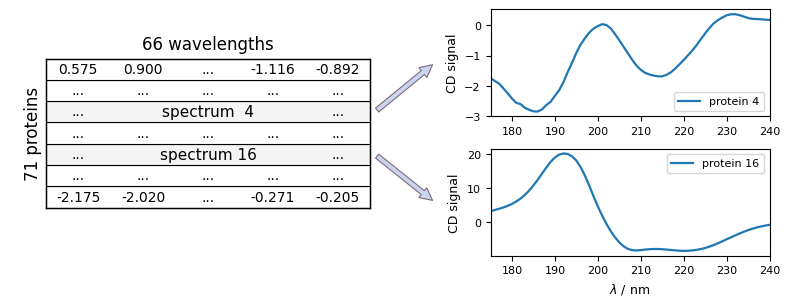

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch, Rectangle

LAM_START = 175
LAM_END = 240
LAM_STEP = 1

lam = np.arange(LAM_START, LAM_END + LAM_STEP, LAM_STEP)

protein_cd = np.loadtxt('../../assets/data/spectral_analysis/protein_cd.txt')
protein_4 = protein_cd[3]
protein_16 = protein_cd[15]

fig = plt.figure(figsize=(9.8, 3.2), constrained_layout=False)
gs = fig.add_gridspec(2, 2, width_ratios=[1.42, 1.0], wspace=0.25, hspace=0.30)
ax_matrix = fig.add_subplot(gs[:, 0])
ax_p4 = fig.add_subplot(gs[0, 1])
ax_p16 = fig.add_subplot(gs[1, 1])

ax_matrix.set_xlim(-0.55, 5.55)
ax_matrix.set_ylim(-0.42, 8.38)
ax_matrix.axis('off')

rows = 7
cols = 5
cell_w = 1.0
cell_h = 0.76
y0 = 1.30

for row in range(rows):
    y = y0 + row * cell_h
    face = '#f5f5f5' if row in {2, 4} else 'white'
    ax_matrix.add_patch(Rectangle((0, y), cols * cell_w, cell_h, facecolor=face, edgecolor='black', linewidth=0.8))

ax_matrix.plot([0, 0], [y0, y0 + rows * cell_h], color='black', linewidth=1.0)
ax_matrix.plot([cols * cell_w, cols * cell_w], [y0, y0 + rows * cell_h], color='black', linewidth=1.0)

ax_matrix.plot([0, cols * cell_w], [y0, y0], color='black', linewidth=1.0)
ax_matrix.plot([0, cols * cell_w], [y0 + rows * cell_h, y0 + rows * cell_h], color='black', linewidth=1.0)

table_rows = [
    ['0.575', '0.900', '...', '-1.116', '-0.892'],
    ['...', '...', '...', '...', '...'],
    ['...', 'spectrum  4', '', '', '...'],
    ['...', '...', '...', '...', '...'],
    ['...', 'spectrum 16', '', '', '...'],
    ['...', '...', '...', '...', '...'],
    ['-2.175', '-2.020', '...', '-0.271', '-0.205'],
]

for row, values in enumerate(table_rows):
    y = y0 + (rows - row - 0.5) * cell_h
    if row in {2, 4}:
        ax_matrix.text(cols * cell_w / 2, y, values[1], ha='center', va='center', fontsize=11)
        ax_matrix.text(0.50 * cell_w, y, '...', ha='center', va='center', fontsize=10)
        ax_matrix.text((cols - 0.50) * cell_w, y, '...', ha='center', va='center', fontsize=10)
    else:
        for col, value in enumerate(values):
            ax_matrix.text((col + 0.5) * cell_w, y, value, ha='center', va='center', fontsize=10)

ax_matrix.text(cols * cell_w / 2, y0 + rows * cell_h + 0.50, '66 wavelengths', ha='center', va='center', fontsize=12)
ax_matrix.text(-0.20, y0 + rows * cell_h / 2, '71 proteins', ha='center', va='center', rotation=90, fontsize=12)

def style_spectrum_axis(ax, y_label=True):
    ax.set_xlim(LAM_START, LAM_END)
    ax.set_xlabel(r'$\lambda$ / nm', fontsize=9)
    if y_label:
        ax.set_ylabel('CD signal', fontsize=9)
    ax.tick_params(labelsize=8)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

ax_p4.plot(lam, protein_4, color='#1f77b4', linewidth=1.6, label='protein 4')
ax_p4.legend(loc='lower right', fontsize=8, frameon=True)
style_spectrum_axis(ax_p4)
ax_p4.set_xlabel('')

ax_p16.plot(lam, protein_16, color='#1f77b4', linewidth=1.6, label='protein 16')
ax_p16.legend(loc='upper right', fontsize=8, frameon=True)
style_spectrum_axis(ax_p16)

for row_index, ax_target in [(2, ax_p4), (4, ax_p16)]:
    y = y0 + (rows - row_index - 0.5) * cell_h
    start = ax_matrix.transData.transform((cols * cell_w + 0.07, y))
    end = ax_target.transAxes.transform((-0.20, 0.5))
    start_fig = fig.transFigure.inverted().transform(start)
    end_fig = fig.transFigure.inverted().transform(end)
    arrow = FancyArrowPatch(
        start_fig,
        end_fig,
        transform=fig.transFigure,
        arrowstyle='simple',
        mutation_scale=18,
        linewidth=0.8,
        facecolor='#c7d4f0',
        edgecolor='#7c6273',
        alpha=0.95,
    )
    fig.add_artist(arrow)

plt.show()

The data set can be downloaded from here: {download}`/assets/data/spectral_analysis/protein_cd.txt`.

This is a text file with values separated by whitespace. This kind of file can be loaded using
the [`np.loadtxt`](https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html) function.

The mandatory argument of `np.loadtxt` is the *path* to the text file. 
We distinguish between *absolute paths* and *relative paths*. 
An absolute path starts from the root of the file system, *e.g.* `/Users/name/course/protein_cd.txt`
on a Unix-like system, or `C:\Users\name\course\protein_cd.txt` on a Windows system.
A relative path starts from the current working directory, *e.g.* `protein_cd.txt` if the file is 
in the same directory as the notebook, or `../data/protein_cd.txt` if it is one directory up and then inside `data`.
It is recommended that you put the data file in the same directory as the notebook, 
so that you can simply use the filename as the path and load the data with
```python
protein_cd = np.loadtxt('protein_cd.txt')
```

Otherwise, use
```python
protein_cd = np.loadtxt('path/to/your/protein_cd.txt')
```

In [10]:
protein_cd = np.loadtxt('../../assets/data/spectral_analysis/protein_cd.txt')

Once the spectral matrix is loaded, we can compute the (thin) SVD.
This type of analysis follows the idea that CD spectra can be decomposed into 
a small number of information-rich spectral components, as discussed by Hennessey and Johnson.[^hj]

[^hj]: J. P. Hennessey Jr., W. C. Johnson Jr., *Biochemistry* **1981**, *20*, 1085&ndash;1094.

In [11]:
u_cd, s_cd, vt_cd = np.linalg.svd(protein_cd, full_matrices=False)

print('data matrix:', protein_cd.shape)
print('U:', u_cd.shape)
print('singular values:', s_cd.shape)
print('V^T:', vt_cd.shape)

data matrix: (71, 66)
U: (71, 66)
singular values: (66,)
V^T: (66, 66)


The singular values tell us how much spectral energy is carried by each component. 
Standard ways of visualising this are the *scree plot* and the *cumulative spectral energy plot*.
In a scree plot, the singular values are plotted in descending order.
In a cumulative spectral energy plot, the cumulative sum of the squares of the singular values is plotted,
normalised by the total sum of the squares of the singular values, *i.e.*,
$$
\text{Cumulative Spectral Energy}(k) = \frac{\sum_{i=1}^k \sigma_i^2}{\sum_{i=1}^p \sigma_i^2} \,.
$$
We shall plot both of them.

In [12]:
cumulative_spectral_energy = np.cumsum(s_cd**2) / np.sum(s_cd**2)

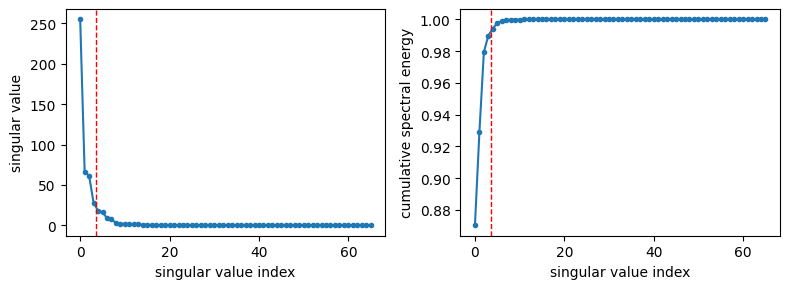

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3))

axs[0].plot(s_cd, marker='.')
axs[0].set_xlabel('singular value index')
axs[0].set_ylabel('singular value')
axs[0].axvline(x=3.5, color='red', linestyle='--', linewidth=1.0)

axs[1].plot(cumulative_spectral_energy, marker='.')
axs[1].set_xlabel('singular value index')
axs[1].set_ylabel('cumulative spectral energy')
axs[1].axvline(x=3.5, color='red', linestyle='--', linewidth=1.0)

fig.tight_layout()

plt.show()

Because we have two different objects to plot, the proper way to do this is to
explicitly create a figure with two subplots using the
[`plt.subplots`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) function.
The first two arguments of `plt.subplots` specify the number of rows and columns of subplots, respectively.
The keyword argument `figsize` specifies the size of the figure in inches.
The function returns a tuple of the figure object and an array of axes objects, which we can
use to plot the two subplots separately.

And in this case, we do not call functions like `plt.plot` or `plt.xlabel` directly, 
but rather call methods of the axes objects, *e.g.* `ax1.plot` or `ax1.set_xlabel`.
Be aware that the methods may have different names from the functions, *e.g.* `set_xlabel` instead of `xlabel`.
We used the [`axes.axvline`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.axvline.html) method 
to add a vertical line between the fourth and fifth singular values. The first four components already
account for almost 99&nbsp;% of the total squared singular-value energy:

In [14]:
print('First cumulative spectral energies:', cumulative_spectral_energy[:4])

First cumulative spectral energies: [0.87017875 0.92891845 0.97934505 0.98975317]


The right singular vectors are the basic patterns that make up the rows
of the data matrix, which are the CD spectra of the proteins.
Therefore, each right singular vector can be interpreted as a spectral component.
We can plot the first four right singular vectors as functions of the wavelength, 
and see what they look like. 

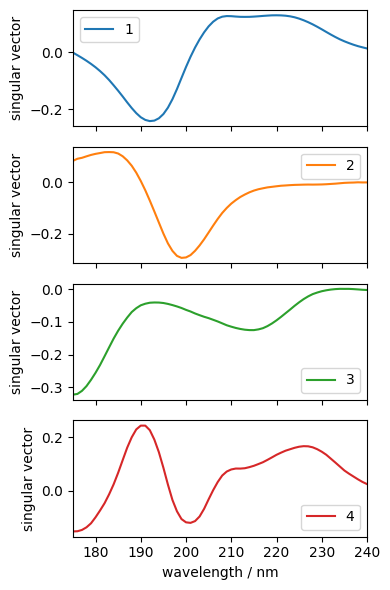

In [15]:
# from the paper of SP175 dataset
wavelengths = np.arange(175, 241)

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

fig, axs = plt.subplots(4, 1, figsize=(4, 6), sharex=True)
for i, ax in enumerate(axs):
    ax.plot(wavelengths, vt_cd[i], c=colors[i], label=(i+1))
    ax.set_ylabel('singular vector')
    ax.set_xlim(175, 240)
    ax.legend()
axs[-1].set_xlabel('wavelength / nm')
fig.tight_layout()
plt.show()

In the code above, we again use `plt.subplots` to create several axes objects at once. 
This time, we create four rows and one column of subplots. 
The keyword argument `sharex=True` tells Matplotlib that all four subplots should use the same 
$x$-axis. This is useful here because all singular vectors are functions of the same wavelength grid. 
In this case, the labels of the $x$-axis ticks are only shown for the bottom subplot.

To loop over the axes, we use the built-in Python function [`enumerate`](https://docs.python.org/3/library/functions.html#enumerate). 
If we write
```python
for i, ax in enumerate(axs):
    ...
```
then `ax` is the current axes object, while `i` is the corresponding counter starting from 0. 
Thus, in the first iteration `i = 0` and `ax = axs[0]`, in the second iteration `i = 1` and `ax = axs[1]`, and so on. 
This is convenient because we need `ax` to draw into the current subplot, 
but we also need `i` to select the corresponding singular vector `vt_cd[i]` and colour `colors[i]`.

Finally, [`ax.set_xlim`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_xlim.html) 
sets the visible range of the x-axis. 
We use `ax.set_xlim(175, 240)` to restrict every subplot to the wavelength range of the CD spectra.

These four spectral components might not tell you much if you do not happen
to be familiar with CD spectra of proteins.
To bridge this gap, we compare them with reference CD spectra for idealised
secondary-structure motifs.[^brahms]

The reference spectra used below are included as text files. You do not need to
download them for the lecture.
If you are curious, or if you want to reproduce the figure yourself, you can
download them here:

:::{table}
:align: center
| Motif | File |
| --- | --- |
| $\alpha$-helix | {download}`/assets/data/spectral_analysis/ref_cd/alpha_helix.txt` |
| random coil | {download}`/assets/data/spectral_analysis/ref_cd/random_coil.txt` |
| $\beta$-sheet | {download}`/assets/data/spectral_analysis/ref_cd/beta_sheet.txt` |
| $\beta$-turn | {download}`/assets/data/spectral_analysis/ref_cd/beta_turn.txt` |
:::

[^brahms]: S. Brahms, J. Brahms, *J. Mol. Biol.* **1980**, *138*, 149&ndash;178.

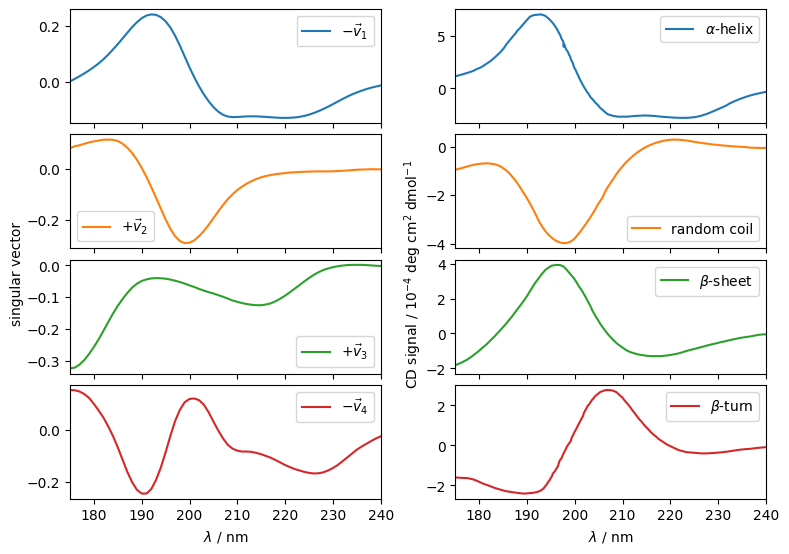

In [16]:
#| label: cd-reference-comparison

reference_files = {
    r'$\alpha$-helix': '../../assets/data/spectral_analysis/ref_cd/alpha_helix.txt',
    'random coil': '../../assets/data/spectral_analysis/ref_cd/random_coil.txt',
    r'$\beta$-sheet': '../../assets/data/spectral_analysis/ref_cd/beta_sheet.txt',
    r'$\beta$-turn': '../../assets/data/spectral_analysis/ref_cd/beta_turn.txt',
}
reference_cd = {name: np.loadtxt(path) for name, path in reference_files.items()}

fig2, axs2 = plt.subplots(4, 2, figsize=(8.0, 5.5))

for ax in axs2[:-1, :].ravel():
    ax.set_xticklabels([])
for ax in axs2.ravel():
    ax.set_xlim(175, 240)

axs2[-1, 0].set_xlabel(r'$\lambda$ / nm', fontsize=10)
axs2[-1, 1].set_xlabel(r'$\lambda$ / nm', fontsize=10)

axs2[0, 0].plot(wavelengths, -vt_cd[0], label=r'$-\vec{v}_1$', c='C0')
axs2[1, 0].plot(wavelengths, vt_cd[1], label=r'$+\vec{v}_2$', c='C1')
axs2[2, 0].plot(wavelengths, vt_cd[2], label=r'$+\vec{v}_3$', c='C2')
axs2[3, 0].plot(wavelengths, -vt_cd[3], label=r'$-\vec{v}_4$', c='C3')

for ax, (name, values), color in zip(axs2[:, 1], reference_cd.items(), ['C0', 'C1', 'C2', 'C3']):
    ax.plot(values[:, 0], values[:, 1], label=name, c=color)

fig2.text(0.025, 0.5, 'singular vector',
          va='center', rotation='vertical', fontsize=10)
fig2.text(0.515, 0.5,
          r'CD signal / $10^{-4}$ deg cm$^2$ dmol$^{-1}$',
          va='center', rotation='vertical', fontsize=10)

for ax in axs2.ravel():
    ax.legend()

fig2.subplots_adjust(
    left=0.10, right=0.97, bottom=0.09, top=0.98,
    hspace=0.10, wspace=0.24,
)

plt.show()

:::{figure} #cd-reference-comparison
:label: fig:cd-reference-comparison
:remove-input:
Comparison of the first four right singular vectors with idealised
reference CD spectra for common secondary-structure motifs.
:::

The comparison is remarkable because the SVD only sees the numerical matrix. 
It does not know what a protein is, what a CD spectrum is, or that secondary-structure motifs exist. 
Nevertheless, the dominant right singular vectors recover patterns that look like familiar CD signatures.

The first component matches the characteristic $\alpha$-helix shape particularly well. 
In fact, the SVD component looks even cleaner than the reference curve because it is extracted 
as the strongest common pattern across the whole data set. Random noise and protein-specific features are averaged out.
The second component also has a clear resemblance to the random-coil reference spectrum, 
especially the strong negative band around 195-200&nbsp;nm.

The third and fourth components are less cleanly assigned to a single motif. 
The third component has some resemblance to the $\beta$-sheet reference, 
for example the broad positive feature around 195&nbsp;nm, but the agreement is not as striking as 
for the first two components. 
The fourth component resembles parts of the $\beta$-turn reference, especially the positive feature 
around 205-210&nbsp;nm, but again it should not be interpreted as a pure $\beta$-turn spectrum. 
This is not a failure of the SVD. Real protein spectra are mixtures of several structural contributions, 
and SVD components are mathematical directions in the data rather than chemically pure spectra. 
In addition, the singular vectors are constrained to be orthogonal to each other, whereas the reference spectra are not.
This mathematical constraint can make later components look like mixtures or corrections rather than pure structural motifs.

This is the main lesson of the example. Without any biochemical labels, SVD distils recurring spectral motifs 
from the data matrix itself. The chemical interpretation comes afterwards, by comparing these data-driven components 
with reference spectra.

## Self-Study Questions

1. Why does `full_matrices=False` give enough information to reconstruct the original matrix?
2. The right singular vectors of the SP175 matrix can be interpreted as component spectra. Can you come up with an interpretation of the left singular vectors?
3. What would change in the interpretation if the spectra were stored as columns instead of rows in the data matrix?
4. What does the sign ambiguity of singular vectors mean for comparing them with reference spectra?
5. Why can noise become less visible when a low-rank approximation is performed?